In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from windrose import WindroseAxes  #using https://pypi.org/project/windrose/
import glob
import os
from datetime import datetime, timedelta

Plot wind speed time series for the four experiments for the urban domain + the whole nested domain - Figure S9 and S12

In [ ]:
#wind speed and direction for urban grid points
def circular_mean_degrees(angles_deg):
    """
    Calculate the circular mean of angles in degrees
    """
    # Convert to radians
    angles_rad = np.radians(angles_deg)
    
    # Convert to unit vectors
    x = np.cos(angles_rad)
    y = np.sin(angles_rad)
    
    # Calculate mean of unit vectors
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Convert back to angle
    mean_angle_rad = np.arctan2(mean_y, mean_x)
    mean_angle_deg = np.degrees(mean_angle_rad)
    
    # Ensure positive angle (0-360)
    if mean_angle_deg < 0:
        mean_angle_deg += 360
        
    return mean_angle_deg

# File paths
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

# Dictionary to store wind component data for each scenario
wind_data = {}

# Process each scenario
for label, sc_path in paths.items():
    print(f"Processing {label}...")
    
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
    print(f"Found {len(file_list)} files for {label}")
    
    # Lists to store time series data
    timestamps = []
    u10_means = []
    v10_means = []
    ws_means = []
    wd_means = []
    
    # Process each file
    for fpath in file_list:
        try:
            # Open dataset
            ds = xr.open_dataset(fpath)
            
            # Parse timestamp and convert to AEST
            timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
            timestamp_aest = timestamp_utc + timedelta(hours=10)
            
            # Extract U10 and V10
            u10 = ds["U10"].where(region_mask)
            v10 = ds["V10"].where(region_mask)

            # Calculate wind speed and direction at each grid point
            ws_grid = np.sqrt(u10**2 + v10**2)
            wd_grid = 180 + (180 / np.pi) * np.arctan2(u10, v10)
            
            # Calculate domain averages
            ws_mean = ws_grid.mean(dim=['south_north', 'west_east']).values.item()
            
            # For wind direction, use circular averaging
            wd_flat = wd_grid.values.flatten()
            # Remove any NaN values
            wd_flat = wd_flat[~np.isnan(wd_flat)]
            wd_mean = circular_mean_degrees(wd_flat)
            
            # Also calculate averages of U and V components for comparison
            u10_mean = u10.mean(dim=['south_north', 'west_east']).values.item()
            v10_mean = v10.mean(dim=['south_north', 'west_east']).values.item()
            
            # Store data
            timestamps.append(timestamp_aest)
            u10_means.append(u10_mean)
            v10_means.append(v10_mean)
            ws_means.append(ws_mean)
            wd_means.append(wd_mean)
                        
            ds.close()
            
        except Exception as e:
            print(f"Error processing {fpath}: {e}")
            continue
    
    # Store results for this scenario
    wind_data[label] = {
        'time': timestamps,
        'U10': u10_means,
        'V10': v10_means,
        'WS': ws_means,
        'WD': wd_means
    }
    
    print(f"Completed {label}: {len(timestamps)} time steps processed")

print("All scenarios processed!")

Processing Default(Bulk+NoUCM)...
Found 241 files for Default(Bulk+NoUCM)
Completed Default(Bulk+NoUCM): 241 time steps processed
Processing LCZ...
Found 241 files for LCZ
Completed LCZ: 241 time steps processed
Processing WSF-MB...
Found 241 files for WSF-MB
Completed WSF-MB: 241 time steps processed
Processing Geoscape...
Found 241 files for Geoscape
Completed Geoscape: 241 time steps processed
All scenarios processed!


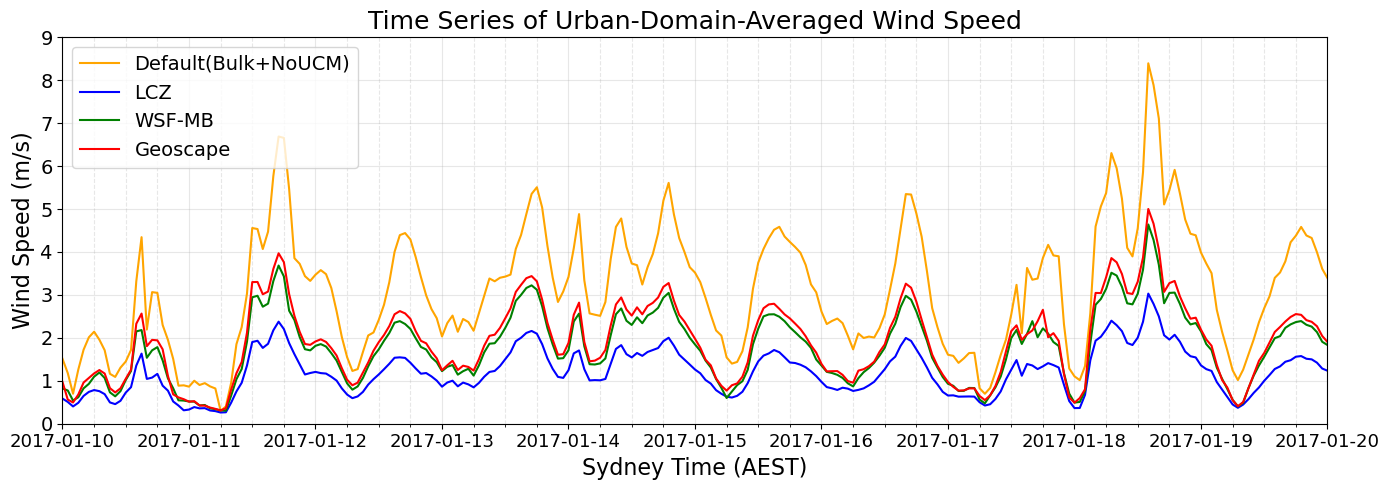

Processing complete!


In [ ]:
#plot wind speed time series averaged over the urban domain
# Define colors for scenarios
colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue', 
    'WSF-MB': 'green',
    'Geoscape': 'red'
}

# Create time series plots
fig, ax = plt.subplots(1, 1, figsize=(14, 5), sharex=True)

# Plot WS
for scenario, data in wind_data.items():
    if data['time']:  # Only plot if data exists
        ax.plot(data['time'], data['WS'], 
                label=scenario, color=colors[scenario], linewidth=1.5)

ax.set_ylabel('Wind Speed (m/s)', fontsize=16)
ax.set_title('Time Series of Urban-Domain-Averaged Wind Speed', fontsize=18) #, fontweight='bold'
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle='--', alpha=0.3)
ax.set_xlabel('Sydney Time (AEST)', fontsize=16)
ax.set_ylim(0, 9)
ax.grid(True, alpha=0.3)

ax.tick_params(axis='y', which='major', labelsize=14)
ax.tick_params(axis='x', which='major', labelsize=13)

# Format x-axis
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Set x-axis limits if data exists
if wind_data:
    first_scenario = list(wind_data.keys())[0]
    if wind_data[first_scenario]['time']:
        ax.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))

plt.tight_layout()
plt.savefig('FigS9-winds_timeseries_urban.png', dpi=300, bbox_inches='tight')
plt.show()
print("Processing complete!")

In [ ]:
#nested domain wind speed and direction
def circular_mean_degrees(angles_deg):
    """
    Calculate the circular mean of angles in degrees
    """
    # Convert to radians
    angles_rad = np.radians(angles_deg)
    
    # Convert to unit vectors
    x = np.cos(angles_rad)
    y = np.sin(angles_rad)
    
    # Calculate mean of unit vectors
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # Convert back to angle
    mean_angle_rad = np.arctan2(mean_y, mean_x)
    mean_angle_deg = np.degrees(mean_angle_rad)
    
    # Ensure positive angle (0-360)
    if mean_angle_deg < 0:
        mean_angle_deg += 360
        
    return mean_angle_deg

# File paths
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Dictionary to store wind component data for each scenario
wind_data = {}

# Process each scenario
for label, sc_path in paths.items():
    print(f"Processing {label}...")
    
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
    print(f"Found {len(file_list)} files for {label}")
    
    # Lists to store time series data
    timestamps = []
    u10_means = []
    v10_means = []
    ws_means = []
    wd_means = []
    
    # Process each file
    for fpath in file_list:
        try:
            # Open dataset
            ds = xr.open_dataset(fpath)
            
            # Parse timestamp and convert to AEST
            timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
            timestamp_aest = timestamp_utc + timedelta(hours=10)
            
            # Extract U10 and V10
            u10 = ds["U10"]
            v10 = ds["V10"]
            
            # Method 1: Calculate wind direction at each grid point, then average circularly
            # Calculate wind speed and direction at each grid point
            ws_grid = np.sqrt(u10**2 + v10**2)
            wd_grid = 180 + (180 / np.pi) * np.arctan2(u10, v10)
            
            # Calculate domain averages
            ws_mean = ws_grid.mean(dim=['south_north', 'west_east']).values.item()
            
            # For wind direction, use circular averaging
            wd_flat = wd_grid.values.flatten()
            # Remove any NaN values
            wd_flat = wd_flat[~np.isnan(wd_flat)]
            wd_mean = circular_mean_degrees(wd_flat)
            
            # Also calculate averages of U and V components for comparison
            u10_mean = u10.mean(dim=['south_north', 'west_east']).values.item()
            v10_mean = v10.mean(dim=['south_north', 'west_east']).values.item()
            
            # Store data
            timestamps.append(timestamp_aest)
            u10_means.append(u10_mean)
            v10_means.append(v10_mean)
            ws_means.append(ws_mean)
            wd_means.append(wd_mean)
            
            ds.close()
            
        except Exception as e:
            print(f"Error processing {fpath}: {e}")
            continue
    
    # Store results for this scenario
    wind_data[label] = {
        'time': timestamps,
        'U10': u10_means,
        'V10': v10_means,
        'WS': ws_means,
        'WD': wd_means
    }
    
    print(f"Completed {label}: {len(timestamps)} time steps processed")

print("All scenarios processed!")


Processing Default(Bulk+NoUCM)...
Found 241 files for Default(Bulk+NoUCM)
Completed Default(Bulk+NoUCM): 241 time steps processed
Processing LCZ...
Found 241 files for LCZ
Completed LCZ: 241 time steps processed
Processing WSF-MB...
Found 241 files for WSF-MB
Completed WSF-MB: 241 time steps processed
Processing Geoscape...
Found 241 files for Geoscape
Completed Geoscape: 241 time steps processed
All scenarios processed!


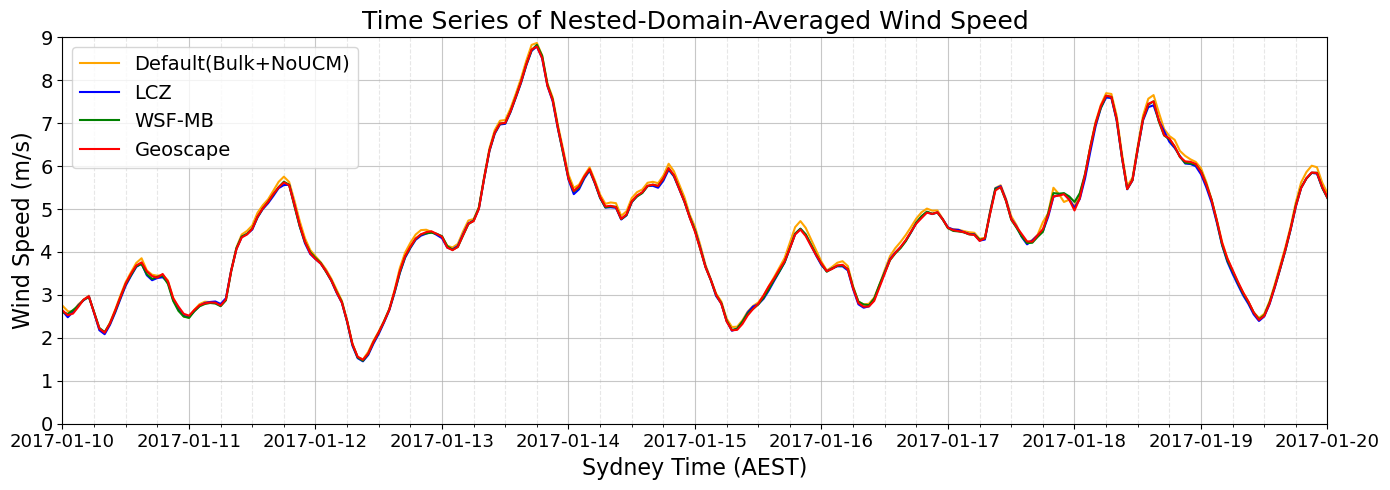

Processing complete!


In [ ]:
#plot nested domain averaged wind speed
# Define colors for scenarios
colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue', 
    'WSF-MB': 'green',
    'Geoscape': 'red'
}

# Create time series plots
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Plot Wind Speed
for scenario, data in wind_data.items():
    if data['time']:  # Only plot if data exists
        ax.plot(data['time'], data['WS'], 
                label=scenario, color=colors[scenario], linewidth=1.5)

ax.set_ylabel('Wind Speed (m/s)', fontsize=16)
ax.set_title('Time Series of Nested-Domain-Averaged Wind Speed', fontsize=18) #, fontweight='bold'
ax.set_ylim(0, 9) 
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, which='major', linestyle='-', alpha=0.7)
ax.grid(True, which='minor', linestyle='--', alpha=0.3)
ax.set_xlabel('Sydney Time (AEST)', fontsize=16)

# Format x-axis
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.tick_params(axis='y', which='major', labelsize=14)
ax.tick_params(axis='x', which='major', labelsize=13)

# Set x-axis limits if data exists
if wind_data:
    first_scenario = list(wind_data.keys())[0]
    if wind_data[first_scenario]['time']:
        ax.set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))

plt.tight_layout()
plt.savefig('FigS12-winds_timeseries_all.png', dpi=300, bbox_inches='tight')
plt.show()
print("Processing complete!")